# 🎓 Student Performance Analysis

## Exploratory Data Analysis (EDA)

A reproducible Jupyter Notebook for analyzing student academic performance.

**Dataset:** `data/student_data.csv`


## 1. Import Libraries

In [26]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 2. Project Paths

In [27]:
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
DATA_FILE = BASE_DIR / "data" / "student_data.csv"
VISUALIZATION_DIR = BASE_DIR / "visualizations"
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)
print("Dataset:", DATA_FILE)
print("Dataset exists:", DATA_FILE.exists())


Dataset: c:\Users\ACO\Desktop\git hub project\Student-Performance-Analysis\data\student_data.csv
Dataset exists: True


## 3. Load Dataset

In [28]:
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find {DATA_FILE}. Put student_data.csv inside data/.")
df = pd.read_csv(DATA_FILE)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Loaded: 395 rows x 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 4. Dataset Overview

In [29]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [30]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## 5. Data Quality

In [31]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())


Duplicate rows: 0

Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


## 6. Statistical Summary

In [32]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


## 7. Final Grade (G3) Analysis

In [33]:
average_g3 = df["G3"].mean()
g3_counts = df["G3"].value_counts().sort_index()
print(f"Average G3: {average_g3:.2f}")
print(f"Most Common G3: {g3_counts.idxmax()}")
print(f"Students with G3 = 20: {(df["G3"] == 20).sum()}")
g3_counts


Average G3: 10.42
Most Common G3: 10
Students with G3 = 20: 1


G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

### Final Grade Distribution

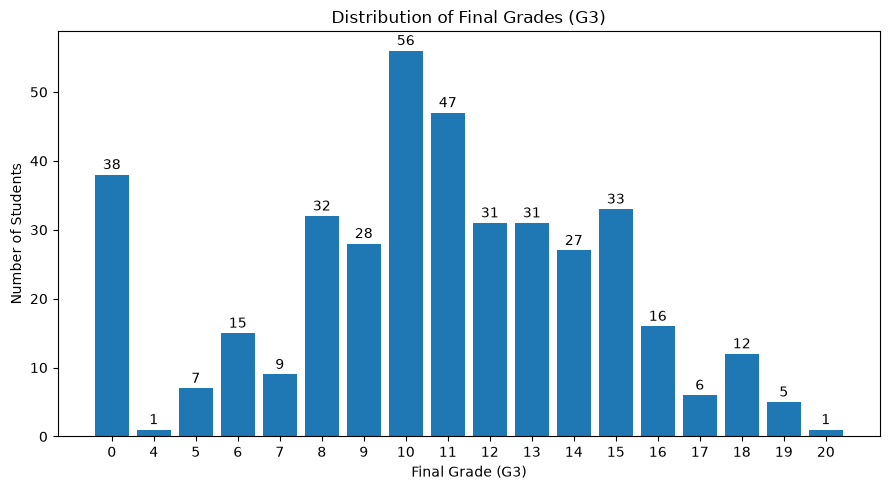

In [34]:
fig, ax = plt.subplots(figsize=(9,5))
bars=ax.bar(g3_counts.index.astype(str),g3_counts.values)
ax.set_title("Distribution of Final Grades (G3)")
ax.set_xlabel("Final Grade (G3)")
ax.set_ylabel("Number of Students")
for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.8,f"{int(b.get_height())}",ha="center")
plt.tight_layout(); plt.show()


## 8. Study Time vs Final Grade

In [35]:
studytime_g3=df.groupby("studytime")["G3"].mean()
studytime_g3


studytime
1   10.05
2   10.17
3   11.40
4   11.26
Name: G3, dtype: float64

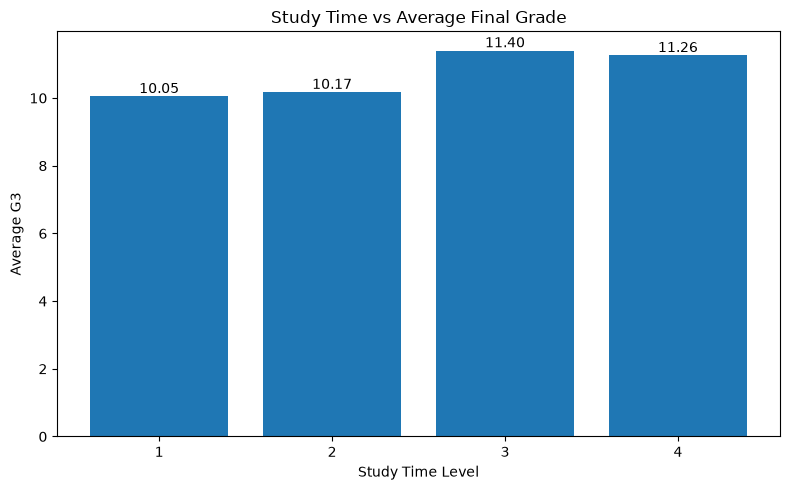

In [36]:
fig,ax=plt.subplots(figsize=(8,5)); bars=ax.bar(studytime_g3.index.astype(str),studytime_g3.values)
ax.set_title("Study Time vs Average Final Grade"); ax.set_xlabel("Study Time Level"); ax.set_ylabel("Average G3")
for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f"{b.get_height():.2f}",ha="center")
plt.tight_layout(); plt.show()


## 9. Previous Failures vs Final Grade

In [37]:
failure_g3=df.groupby("failures")["G3"].mean(); failure_g3


failures
0   11.25
1    8.12
2    6.24
3    5.69
Name: G3, dtype: float64

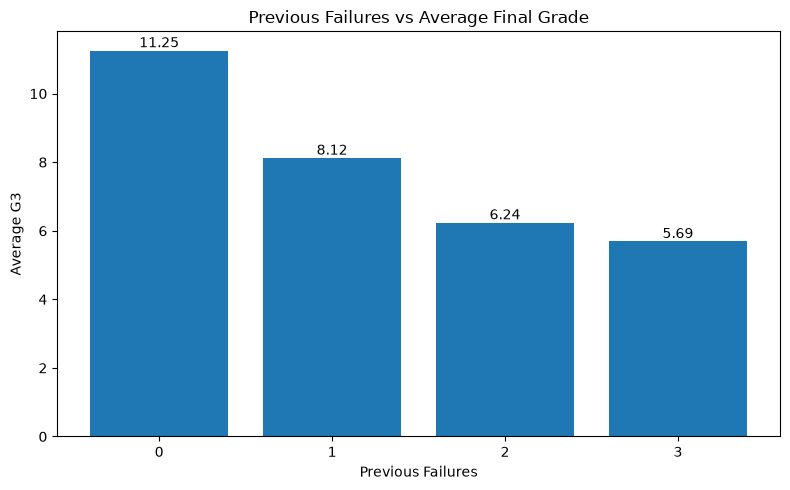

In [38]:
fig,ax=plt.subplots(figsize=(8,5)); bars=ax.bar(failure_g3.index.astype(str),failure_g3.values)
ax.set_title("Previous Failures vs Average Final Grade"); ax.set_xlabel("Previous Failures"); ax.set_ylabel("Average G3")
for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f"{b.get_height():.2f}",ha="center")
plt.tight_layout(); plt.show()


## 10. Absences vs Final Grade

In [39]:
absence_correlation=df["absences"].corr(df["G3"])
print(f"Absence vs G3 Correlation: {absence_correlation:.6f}")


Absence vs G3 Correlation: 0.034247


## 11. Gender vs Final Grade

In [40]:
gender_g3=df.groupby("sex")["G3"].mean(); gender_g3


sex
F    9.97
M   10.91
Name: G3, dtype: float64

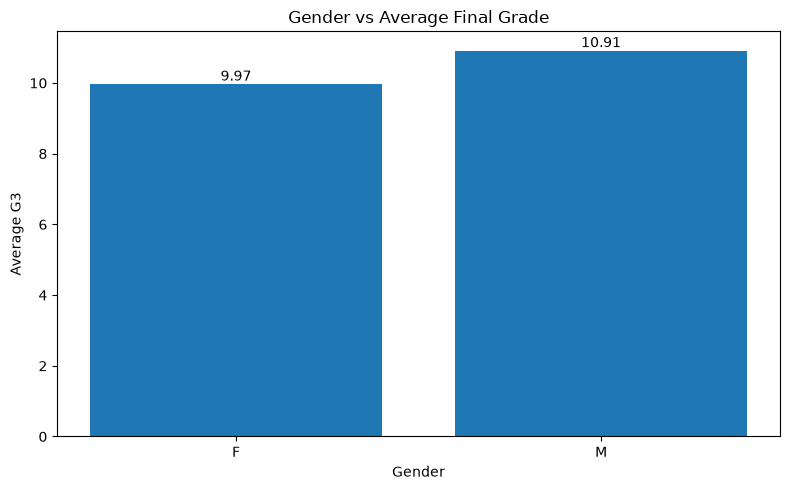

In [41]:
fig,ax=plt.subplots(figsize=(8,5)); bars=ax.bar(gender_g3.index.astype(str),gender_g3.values)
ax.set_title("Gender vs Average Final Grade"); ax.set_xlabel("Gender"); ax.set_ylabel("Average G3")
for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f"{b.get_height():.2f}",ha="center")
plt.tight_layout(); plt.show()


## 12. Address Type vs Final Grade

In [42]:
address_g3=df.groupby("address")["G3"].mean(); address_g3


address
R    9.51
U   10.67
Name: G3, dtype: float64

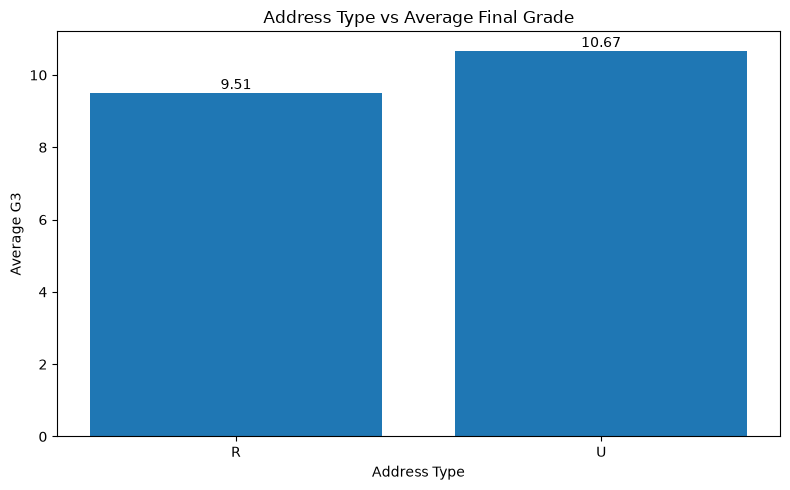

In [43]:
fig,ax=plt.subplots(figsize=(8,5)); bars=ax.bar(address_g3.index.astype(str),address_g3.values)
ax.set_title("Address Type vs Average Final Grade"); ax.set_xlabel("Address Type"); ax.set_ylabel("Average G3")
for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f"{b.get_height():.2f}",ha="center")
plt.tight_layout(); plt.show()


## 13. Mother's Education vs Final Grade

In [44]:
mother_education_g3=df.groupby("Medu")["G3"].mean()
print("Average G3:"); display(mother_education_g3)
print("Student count:"); display(df["Medu"].value_counts().sort_index())


Average G3:


Medu
0   13.00
1    8.68
2    9.73
3   10.30
4   11.76
Name: G3, dtype: float64

Student count:


Medu
0      3
1     59
2    103
3     99
4    131
Name: count, dtype: int64

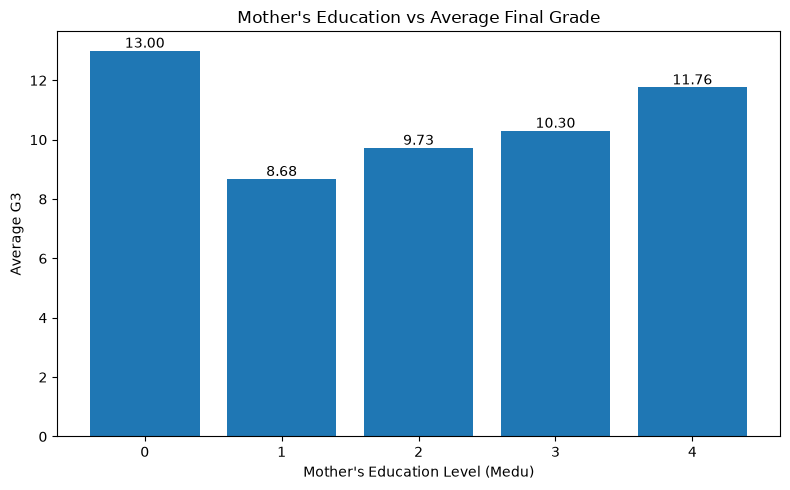

In [45]:
fig,ax=plt.subplots(figsize=(8,5)); bars=ax.bar(mother_education_g3.index.astype(str),mother_education_g3.values)
ax.set_title("Mother's Education vs Average Final Grade"); ax.set_xlabel("Mother's Education Level (Medu)"); ax.set_ylabel("Average G3")
for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f"{b.get_height():.2f}",ha="center")
plt.tight_layout(); plt.show()


## 14. Father's Education vs Final Grade

In [46]:
father_education_g3=df.groupby("Fedu")["G3"].mean()
print("Average G3:"); display(father_education_g3)
print("Student count:"); display(df["Fedu"].value_counts().sort_index())


Average G3:


Fedu
0   13.00
1    9.16
2   10.26
3   10.66
4   11.36
Name: G3, dtype: float64

Student count:


Fedu
0      2
1     82
2    115
3    100
4     96
Name: count, dtype: int64

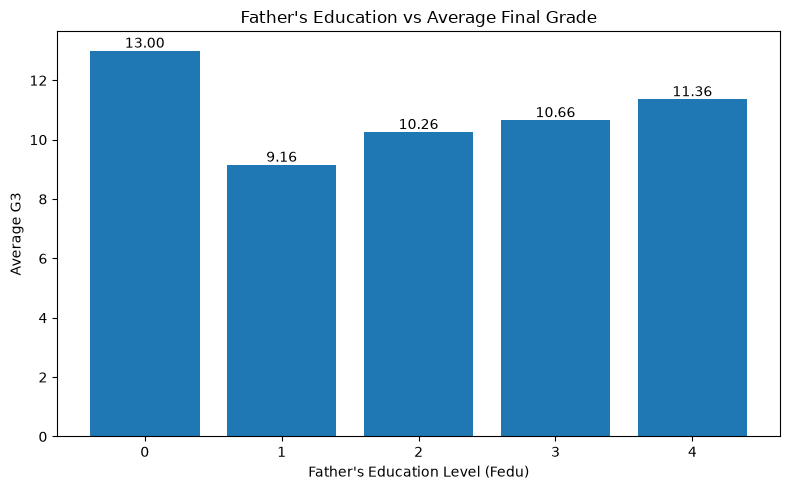

In [47]:
fig,ax=plt.subplots(figsize=(8,5)); bars=ax.bar(father_education_g3.index.astype(str),father_education_g3.values)
ax.set_title("Father's Education vs Average Final Grade"); ax.set_xlabel("Father's Education Level (Fedu)"); ax.set_ylabel("Average G3")
for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f"{b.get_height():.2f}",ha="center")
plt.tight_layout(); plt.show()


## 15. Correlation Between G1, G2 and G3

In [48]:
grade_correlation=df[["G1","G2","G3"]].corr()
grade_correlation


,G1,G2,G3
G1,1.00,0.85,0.80
G2,0.85,1.00,0.90
G3,0.80,0.90,1.00


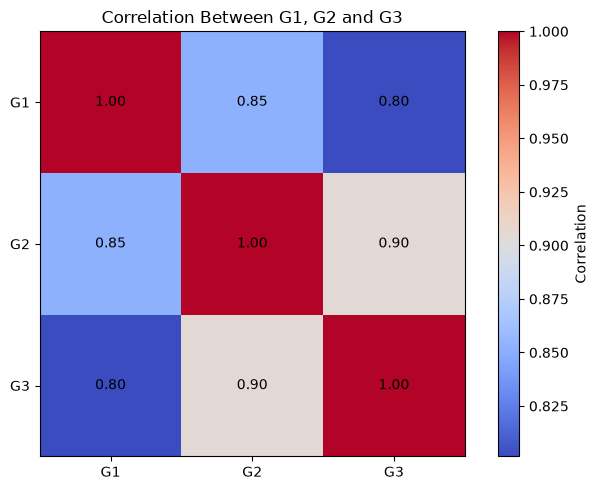

In [49]:
fig,ax=plt.subplots(figsize=(7,5)); image=ax.imshow(grade_correlation,cmap="coolwarm"); fig.colorbar(image,ax=ax,label="Correlation")
ax.set_xticks(range(3)); ax.set_xticklabels(grade_correlation.columns); ax.set_yticks(range(3)); ax.set_yticklabels(grade_correlation.index)
ax.set_title("Correlation Between G1, G2 and G3")
for i in range(3):
    for j in range(3): ax.text(j,i,f"{grade_correlation.iloc[i,j]:.2f}",ha="center",va="center")
plt.tight_layout(); plt.show()


## 16. Key Findings

- The dataset contains **395 students and 33 variables**.
- The analyzed dataset has **0 duplicate rows** and **0 missing values**.
- Average final grade (`G3`) is approximately **10.42**.
- `G2` has a stronger positive correlation with `G3` (~**0.90**) than `G1` with `G3` (~**0.80**).
- Students with more previous failures have lower average G3 in this dataset.
- Study-time levels 3 and 4 have higher average G3 than levels 1 and 2.
- Absence vs G3 correlation is approximately **0.03**, a very weak linear relationship.
- Parental-education groups show generally higher average grades at higher levels, but small groups should be interpreted cautiously.

**Note:** These are associations, not proof of causation.


## 17. Save Main Visualizations

In [50]:
def save_bar(series,title,xlabel,filename):
    fig,ax=plt.subplots(figsize=(8,5)); bars=ax.bar(series.index.astype(str),series.values)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("Average G3")
    for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+.1,f"{b.get_height():.2f}",ha="center")
    fig.tight_layout(); fig.savefig(VISUALIZATION_DIR/filename,dpi=300,bbox_inches="tight"); plt.close(fig)

save_bar(failure_g3,"Previous Failures vs Average Final Grade","Previous Failures","failures_vs_g3.png")
save_bar(studytime_g3,"Study Time vs Average Final Grade","Study Time Level","studytime_vs_g3.png")
save_bar(gender_g3,"Gender vs Average Final Grade","Gender","gender_vs_g3.png")
save_bar(address_g3,"Address Type vs Average Final Grade","Address Type","address_vs_g3.png")
save_bar(mother_education_g3,"Mother's Education vs Average Final Grade","Mother's Education Level (Medu)","mothers_education_vs_g3.png")
save_bar(father_education_g3,"Father's Education vs Average Final Grade","Father's Education Level (Fedu)","fathers_education_vs_g3.png")
print("Charts saved to", VISUALIZATION_DIR)


Charts saved to c:\Users\ACO\Desktop\git hub project\Student-Performance-Analysis\visualizations


## ✅ Conclusion

This notebook provides a complete Pandas + Matplotlib EDA workflow and is ready to publish alongside the Python script on GitHub.